# Transient Generators

Transient generators produce single-event signals used primarily for system characterisation. Any LTI system's impulse response completely describes its behaviour; the step response is its integral.

| Function | Description |
| --- | --- |
| `generate_impulse` | A single sample of value `amplitude` at time `delay` seconds; all other samples are zero. The digital Dirac delta δ[n]. Convolving a system with its impulse response gives its output for *any* input. |
| `generate_step` | Signal that jumps from 0 to `amplitude` at `onset` seconds and stays there. The integral of the impulse; reveals DC gain, ringing, and settling time of a system. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_impulse, generate_step

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Side-by-side time-domain plots over a short window.

**Left — impulse at t = 0 ms (5 ms window):**
- A single spike of amplitude 1 at sample 0; every other sample is exactly zero
- Because the impulse contains equal energy at all frequencies (flat spectrum), running it through any filter directly reveals the filter's time-domain behaviour
- Markers show individual samples, making the single-sample width visible

**Right — step with onset at 2 ms (10 ms window):**
- Zero before the onset, 1.0 from the onset onwards
- The ramp-like transition is only one sample wide (the sampling grid is visible)
- Useful for measuring filter latency (when does the output first become non-zero?), overshoot, and the DC steady-state gain

Both signals have exact analytical spectra — the impulse has a flat spectrum and the step has a 1/f spectrum — making them ideal as calibration inputs.


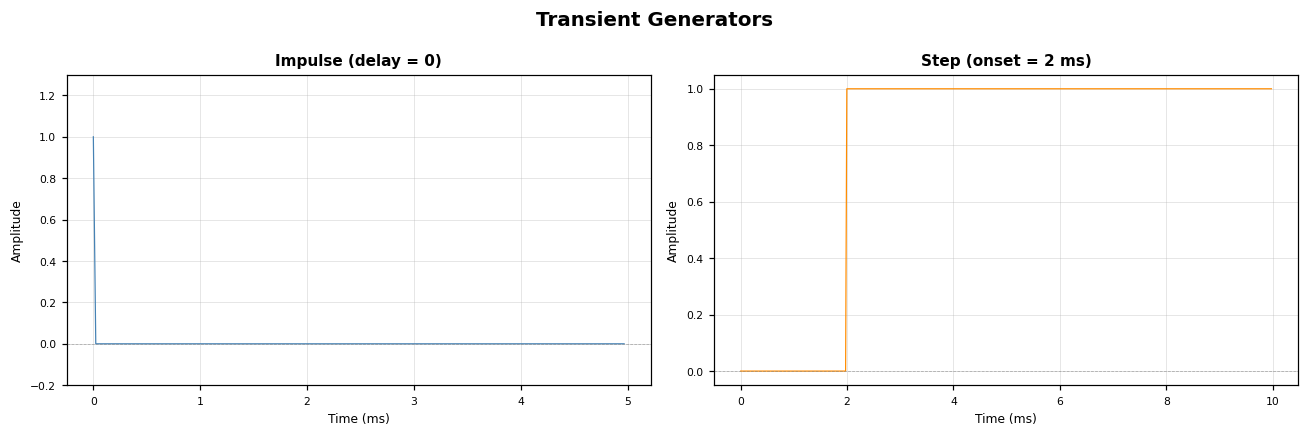

In [2]:
def _ms(ms: float) -> float:
    return ms / 1000.0


FS = 44100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

t, wave = generate_impulse(fs=FS, duration=_ms(5), delay=0.0)
axes[0].plot(t * 1000, wave, linewidth=0.8, color="steelblue")
axes[0].set_title("Impulse (delay = 0)", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Time (ms)", fontsize=8)
axes[0].set_ylabel("Amplitude", fontsize=8)
axes[0].set_ylim(-0.2, 1.3)

t, wave = generate_step(fs=FS, duration=_ms(10), onset=_ms(2))
axes[1].plot(t * 1000, wave, linewidth=0.8, color="darkorange")
axes[1].set_title("Step (onset = 2 ms)", fontsize=10, fontweight="bold")
axes[1].set_xlabel("Time (ms)", fontsize=8)
axes[1].set_ylabel("Amplitude", fontsize=8)

for ax in axes:
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--", alpha=0.6)

fig.suptitle("Transient Generators", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()